# Case 3: 2D CO2 Displacement of Brine — an ICFERST-informed PINN

## 1. Learning objectives and scope

This university tutorial connects a verified two-phase ICFERST simulation to a
physics-informed neural network (PINN). You will learn to separate sparse observations
from unlabeled collocation points, construct two phase-balance residuals, validate at
complete unseen times, and interpret front and inventory errors.

The goal is a transparent teaching benchmark. It is **not a calibrated storage-site model**.

## 2. Physical problem, assumptions, and fixed parameters

Supercritical CO2 enters the left edge of a homogeneous $300\,\mathrm{m}\times150\,\mathrm{m}$
rectangle and displaces brine toward a fixed-pressure outlet. The simulation lasts 300 days.
Porosity is 0.20 and isotropic permeability is $10^{-12}\,\mathrm{m^2}$. Densities are
1000 and 700 kg/m³; viscosities are $10^{-3}$ and $7\times10^{-5}$ Pa s. Residual brine
saturation is 0.20, and both Corey exponents are 2.

The inlet profile is
$$q(y)=10^{-6}\left[1+0.5\cos\left(2\pi(y/150-0.5)\right)\right]\ \mathrm{m/s}.$$

We deliberately neglect gravity, capillary pressure, dissolution, compressibility, and
heterogeneity so that students can focus on two-phase conservation and PINN validation.

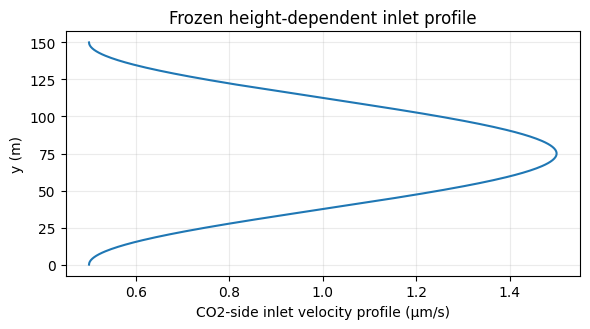

In [1]:
import hashlib, io, math, os, pathlib, random, urllib.request
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
LX, LY, FINAL_TIME = 300.0, 150.0, 300.0*86400.0
PHI, K = 0.20, 1.0e-12
MU_BRINE, MU_CO2 = 1.0e-3, 7.0e-5
SWR, S_CO2_MAX = 0.20, 0.80
Q0, P_OUT, P_SCALE = 1.0e-6, 1.0e7, 2.0e5
INITIAL_GATE_TIME = 86400.0

def inlet_flux(y_m):
    return Q0*(1.0 + 0.5*np.cos(2.0*np.pi*(y_m/LY - 0.5)))

y_line = np.linspace(0.0, LY, 301)
plt.figure(figsize=(6, 3.4))
plt.plot(inlet_flux(y_line)*1e6, y_line)
plt.xlabel("CO2-side inlet velocity profile (µm/s)"); plt.ylabel("y (m)")
plt.title("Frozen height-dependent inlet profile"); plt.grid(alpha=0.25)
plt.tight_layout(); plt.show()

## 3. ICFERST reference simulation and provenance

This classroom notebook does **not** run ICFERST. It directly consumes the prepared,
checksum-verified NPZ reference dataset so class time can focus on the PINN. The original
mesh, MPML input, metadata, checksum manifest, and Host B validation report are supplied as
separate reproducibility attachments.

ICFERST solved the fixed two-phase problem on a 61×31-vertex triangular mesh with a one-day
time step. The accepted Host B run reached 25,920,000 s with return code zero. Sixteen unique
snapshots passed finite-value, saturation-sum, monotone-inventory, and checksum checks; the
injected-versus-stored/outflow mismatch was 0.536%.

ICFERST applies the inlet phase fractions weakly. Consequently, exported discontinuous-
Galerkin values located at $x=0$ are cell-field values, not the exact mathematical boundary
trace $S_{CO2}=0.8$. The PINN therefore learns the exported field while the prescribed phase
flux terms carry the inlet physics; these two quantities should not be conflated.

The compact NPZ contains ICFERST reference fields and immutable split indices. Its SHA-256 is
checked before loading. If direct Drive download is unavailable, Colab presents a file-upload
widget. ICFERST values are reference simulation results, not analytical truth.

In [2]:
DATA_FILE_ID = '1e0yZojBHXSHpxYfyT_xXlMYcI7fJiM-R'
DATA_SHA256 = '503c2bd1c2672e2cdfa3d41442c312582c4e7eb0a2c3c9e69ad86e0f8de24940'
DATA_NAME = "co2_brine_icferst_teaching.npz"

def sha256_bytes(payload):
    return hashlib.sha256(payload).hexdigest()

def obtain_dataset_bytes():
    local = pathlib.Path(DATA_NAME)
    if not local.is_file() and (pathlib.Path("data")/DATA_NAME).is_file():
        local = pathlib.Path("data")/DATA_NAME
    if local.is_file():
        payload = local.read_bytes()
    elif DATA_FILE_ID != "PENDING_DRIVE_UPLOAD":
        url = f"https://drive.google.com/uc?export=download&id={DATA_FILE_ID}"
        try:
            with urllib.request.urlopen(url, timeout=60) as response:
                payload = response.read()
        except Exception as error:
            print(f"Direct download failed ({error}); opening the upload widget.")
            from google.colab import files
            payload = next(iter(files.upload().values()))
    else:
        print("The Drive ID has not been injected; opening the upload widget.")
        from google.colab import files
        payload = next(iter(files.upload().values()))
    observed = sha256_bytes(payload)
    if observed != DATA_SHA256:
        raise ValueError(f"Dataset SHA-256 mismatch: {observed}")
    print(f"Dataset verified: {observed}")
    return payload

DATA = {}
with np.load(io.BytesIO(obtain_dataset_bytes())) as archive:
    DATA.update({name: archive[name] for name in archive.files})
print({name: value.shape for name, value in DATA.items()})

ValueError: Dataset SHA-256 mismatch: 49068358e924c5b02011d3617083b4e302c657427b55c50c6f9924b494bf2547

## 4. Load and visualize the simulation data

The plots below show selected ICFERST saturation snapshots. The curved front is caused by the
nonuniform inlet profile. Repeated discontinuous-Galerkin point coordinates are averaged only
for visualization; all stored rows remain available for training and evaluation.

In [ ]:
def unique_xy_field(rows, values):
    xy = np.column_stack((DATA["x_m"][rows], DATA["y_m"][rows]))
    unique, inverse = np.unique(xy, axis=0, return_inverse=True)
    averaged = np.bincount(inverse, weights=values)/np.bincount(inverse)
    return unique[:, 0], unique[:, 1], averaged

figure, axes = plt.subplots(1, 3, figsize=(13, 3.6), constrained_layout=True)
snapshot_ids = np.unique(DATA["snapshot_id"])
for axis, sid in zip(axes, snapshot_ids[[4, 9, 15]]):
    rows = np.flatnonzero(DATA["snapshot_id"] == sid)
    x, y, s = unique_xy_field(rows, DATA["s_co2"][rows])
    artist = axis.tricontourf(x, y, s, levels=np.linspace(0, 0.8, 21), cmap="plasma")
    axis.set(xlabel="x (m)", ylabel="y (m)",
             title=f"ICFERST, t={DATA['time_s'][rows[0]]/86400:.0f} days")
figure.colorbar(artist, ax=axes, label="CO2 saturation (-)")
plt.show()

## 5. Governing equations and nondimensionalization

With $S_b=1-S_c$, common pressure, and no gravity or capillarity,
$$\phi\partial_t S_\alpha+\nabla\cdot\mathbf v_\alpha=0,\qquad
\mathbf v_\alpha=-\frac{Kk_{r\alpha}}{\mu_\alpha}\nabla p.$$
Effective CO2 saturation is $S_c/0.8$, so $k_{rc}=(S_c/0.8)^2$ and
$k_{rb}=(1-S_c/0.8)^2$. Coordinates are mapped to $[-1,1]^3$ inside the network.
Residuals are multiplied by $T/\phi$ so their numerical scale is suitable for optimization.

In [ ]:
def relative_permeability(s_co2):
    effective = torch.clamp(s_co2/S_CO2_MAX, 0.0, 1.0)
    return (1.0-effective).square(), effective.square()

def gradient(output, inputs):
    return torch.autograd.grad(output, inputs, torch.ones_like(output),
                               create_graph=True, retain_graph=True)[0]

## 6. Leakage-free train and validation split

Four complete times are held out. At all other times, no more than 10% of eligible interior
rows carry pressure and saturation labels. PDE collocation rows carry coordinates only—never
ICFERST targets. This prevents a common form of validation leakage.

In [ ]:
heldout = DATA["heldout_rows"]
observed = DATA["observation_rows"]
assert not np.intersect1d(heldout, observed).size
print(f"Sparse labeled rows: {observed.size:,}")
print(f"Held-out rows: {heldout.size:,}; held-out snapshots: {DATA['heldout_snapshot_ids']}")
plt.figure(figsize=(7, 3.7))
show_obs = observed[::max(1, observed.size//2500)]
show_test = heldout[::max(1, heldout.size//2500)]
plt.scatter(DATA["time_s"][show_obs]/86400, DATA["x_m"][show_obs], s=3, label="Sparse observations")
plt.scatter(DATA["time_s"][show_test]/86400, DATA["x_m"][show_test], s=3, label="Held-out truth")
plt.xlabel("Time (days)"); plt.ylabel("x (m)"); plt.legend(); plt.title("Leakage-free split")
plt.tight_layout(); plt.show()

## 7. Two-branch PINN architecture

Separate tanh MLPs represent pressure and saturation. Pressure is scaled around the 10 MPa
outlet value. A hard one-day gate enforces the initially uniform pressure and zero CO2
saturation exactly. The saturation branch receives only $q(y)/q_0$ and the
Buckley--Leverett similarity coordinate $x/[q(y)t]$, directly enforcing the self-similar
displacement structure supported by the training snapshots. This resolves a narrow early
plume without using held-out labels. The sigmoid output enforces $0\le S_{CO2}\le0.8$.

In [ ]:
def make_mlp(width, depth, input_features=3):
    layers=[]; inputs=input_features
    for _ in range(depth):
        layers += [nn.Linear(inputs, width), nn.Tanh()]; inputs=width
    layers += [nn.Linear(inputs, 1)]
    network=nn.Sequential(*layers)
    for layer in network:
        if isinstance(layer, nn.Linear):
            nn.init.xavier_normal_(layer.weight); nn.init.zeros_(layer.bias)
    return network

def saturation_features(xyt):
    xf=xyt[:,0:1]/LX; yf=xyt[:,1:2]/LY; tf=xyt[:,2:3]/FINAL_TIME
    flux_ratio=1.0+0.5*torch.cos(2.0*math.pi*(yf-0.5))
    positive=tf>0.0
    travel_scale=torch.where(positive,flux_ratio*tf,torch.ones_like(tf))
    similarity=torch.where(positive,xf/travel_scale,torch.zeros_like(xf))
    return torch.cat((flux_ratio,similarity),dim=1)

class TwoBranchPINN(nn.Module):
    def __init__(self, width=64, depth=4):
        super().__init__()
        self.pressure_branch=make_mlp(width, depth)
        self.saturation_branch=make_mlp(width, depth, input_features=2)
        self.register_buffer("lower", torch.tensor([0., 0., 0.]))
        self.register_buffer("upper", torch.tensor([LX, LY, FINAL_TIME]))
    def forward(self, xyt):
        z=2.0*(xyt-self.lower)/(self.upper-self.lower)-1.0
        gate=-torch.expm1(-xyt[:,2:3]/INITIAL_GATE_TIME)
        pressure=P_OUT+gate*P_SCALE*self.pressure_branch(z)
        saturation=gate*S_CO2_MAX*torch.sigmoid(self.saturation_branch(saturation_features(xyt)))
        return pressure, saturation

## 8. Physics, data, initial, and boundary losses

The objective includes both phase mass balances, sparse pressure and saturation observations,
the initially brine-filled state, inlet saturation/flux, outlet pressure, top/bottom no-flow,
and a global injected-inventory constraint. Only the two data terms use ICFERST point labels.

In [ ]:
def phase_fields(model, xyt):
    xyt=xyt.requires_grad_(True); pressure, saturation=model(xyt)
    grad_p=gradient(pressure, xyt); krb, krc=relative_permeability(saturation)
    vb=-K*krb/MU_BRINE*grad_p[:, :2]; vc=-K*krc/MU_CO2*grad_p[:, :2]
    return xyt,pressure,saturation,vb,vc

def phase_residuals(model, xyt):
    xyt,pressure,saturation,vb,vc=phase_fields(model,xyt)
    dsdt=gradient(saturation, xyt)[:, 2:3]
    divergence=[]
    for velocity in (vb, vc):
        value=0.0
        for component in range(2):
            value=value+gradient(velocity[:, component:component+1], xyt)[:, component:component+1]
        divergence.append(value)
    scale=FINAL_TIME/PHI
    return scale*(-PHI*dsdt+divergence[0]), scale*(PHI*dsdt+divergence[1])

def xyt(rows):
    return np.column_stack((DATA["x_m"][rows], DATA["y_m"][rows], DATA["time_s"][rows])).astype("float32")

def sample_batch(n_pde, n_obs, n_constraint, rng):
    pde_rows=rng.choice(DATA["collocation_pool_rows"], n_pde, replace=True)
    obs_rows=rng.choice(DATA["observation_rows"], n_obs, replace=True)
    xy=rng.random((n_constraint,2))*[LX,LY]
    initial=np.c_[xy, np.zeros(n_constraint)].astype("float32")
    y=rng.random(n_constraint)*LY; t=rng.random(n_constraint)*FINAL_TIME
    inlet=np.c_[np.zeros(n_constraint),y,t].astype("float32")
    outlet=np.c_[np.full(n_constraint,LX),y,t].astype("float32")
    half=n_constraint//2
    walls=np.c_[rng.random(n_constraint)*LX,
                np.r_[np.zeros(half),np.full(n_constraint-half,LY)],
                rng.random(n_constraint)*FINAL_TIME].astype("float32")
    geometry_rows=np.flatnonzero(DATA["snapshot_id"]==0)
    inventory_time=20.0*86400.0
    inventory=np.c_[DATA["x_m"][geometry_rows],DATA["y_m"][geometry_rows],
                    np.full(geometry_rows.size,inventory_time)].astype("float32")
    inventory_target=np.array([[S_CO2_MAX*Q0*inventory_time/(PHI*LX)]],dtype="float32")
    return {
        "pde": {"xyt": xyt(pde_rows)},
        "obs": {"xyt": xyt(obs_rows), "pressure": DATA["pressure_pa"][obs_rows,None].astype("float32"),
                 "s_co2": DATA["s_co2"][obs_rows,None].astype("float32")},
        "initial": initial,
        "inlet": {"xyt":inlet,"flux":inlet_flux(y).astype("float32")[:,None]},
        "outlet": outlet, "walls":walls,
        "inventory":{"xyt":inventory,
                     "time_group":np.zeros((geometry_rows.size,1),dtype="int64"),
                     "mean_target":inventory_target},
    }

def time_balanced_saturation_mse(prediction, truth, time_s):
    terms=[]
    for value in torch.unique(time_s.detach()):
        selected=time_s[:,0]==value
        error_energy=(prediction[selected]-truth[selected]).square().mean()
        truth_energy=truth[selected].square().mean()
        terms.append(0.1**2*error_energy/(truth_energy+0.01**2))
    return torch.stack(terms).mean()

def compute_losses(model, batch, device, weights=None):
    tensor=lambda value: torch.as_tensor(value, dtype=torch.float32, device=device)
    rb,rc=phase_residuals(model,tensor(batch["pde"]["xyt"]))
    obs_xyt=tensor(batch["obs"]["xyt"]); obs_s=tensor(batch["obs"]["s_co2"])
    po,so=model(obs_xyt); _,si=model(tensor(batch["initial"]))
    _,pin,sin,vbin,vcin=phase_fields(model,tensor(batch["inlet"]["xyt"]))
    pout,_=model(tensor(batch["outlet"])); _,_,_,vbwall,vcwall=phase_fields(model,tensor(batch["walls"]))
    _,sinventory=model(tensor(batch["inventory"]["xyt"]))
    inventory_terms=[]
    groups=tensor(batch["inventory"]["time_group"])
    targets=tensor(batch["inventory"]["mean_target"])
    for group in range(targets.shape[0]):
        selected=groups[:,0]==float(group)
        inventory_terms.append((sinventory[selected].mean()-targets[group,0]).square())
    losses={
        "pde_brine": rb.square().mean(), "pde_co2": rc.square().mean(),
        "data_pressure": ((po-tensor(batch["obs"]["pressure"]))/P_SCALE).square().mean(),
        "data_saturation": time_balanced_saturation_mse(so,obs_s,obs_xyt[:,2:3]),
        "initial": si.square().mean(),
        "inlet": (sin-S_CO2_MAX).square().mean()
                 +((vcin[:,0:1]-S_CO2_MAX*tensor(batch["inlet"]["flux"]))/Q0).square().mean()
                 +(vbin[:,0:1]/Q0).square().mean(),
        "outlet": ((pout-P_OUT)/P_SCALE).square().mean(),
        "no_flow": (vbwall[:,1:2]/Q0).square().mean()+(vcwall[:,1:2]/Q0).square().mean(),
        "inventory": torch.stack(inventory_terms).mean(),
    }
    active={"pde_brine":1,"pde_co2":1,"data_pressure":1,"data_saturation":10,
            "initial":5,"inlet":2,"outlet":1,"no_flow":1,"inventory":1}
    if weights: active.update(weights)
    losses["total"]=sum(active[name]*value for name,value in losses.items())
    return losses

## 9. GPU-first training with CPU fallback

A real CUDA tensor operation is required before selecting a GPU. Any initialization failure
is reported and execution immediately continues on CPU. `FAST_MODE=True` is the recommended
classroom setting; the accurate setting uses more samples and iterations. Training has two
explicit stages: the self-similar saturation branch is first fitted only to sparse rows from
the earliest nonzero training snapshot (40 days), then frozen while pressure and the two
phase-balance residuals are optimized. Held-out rows never enter either stage.

In [ ]:
def select_device(probe=None):
    if torch.cuda.is_available():
        try:
            device=torch.device("cuda")
            if probe is None:
                value=torch.ones(1,device=device); assert (value*value).item()==1.0
            else: probe(device)
            print(f"Using GPU: {torch.cuda.get_device_name(0)}"); return device
        except Exception as error:
            print(f"CUDA probe failed ({error}); switching immediately to CPU.")
    else: print("No usable GPU is available; using CPU.")
    return torch.device("cpu")

def train_model(data, fast_mode=True):
    device=select_device(); smoke=os.environ.get("PINN_SMOKE","0")=="1"
    config={"iterations":5 if smoke else (3000 if fast_mode else 12000),
            "n_pde":64 if smoke else 512,
            "n_obs":64 if smoke else (512 if fast_mode else 8192),
            "n_constraint":32 if smoke else (128 if fast_mode else 256),
            "width":32 if smoke else (64 if fast_mode else 96),
            "depth":2 if smoke else (4 if fast_mode else 5),
            "learning_rate":1e-3 if (smoke or fast_mode) else 5e-4,
            "final_learning_rate":1e-3 if smoke else (5e-5 if fast_mode else 2e-5),
            "saturation_pretrain_iterations":2 if smoke else 6000,
            "saturation_pretrain_batch_size":64 if smoke else 8192}
    accurate_weights=None if (smoke or fast_mode) else {
        "pde_brine":.1,"pde_co2":.1,"data_pressure":20,"data_saturation":100,
        "initial":10,"inlet":5,"inventory":100,"no_flow":.5}
    model=TwoBranchPINN(config["width"],config["depth"]).to(device)
    obs_rows=DATA["observation_rows"]
    obs_times=DATA["time_s"][obs_rows]
    earliest=obs_times[obs_times>0].min()
    pretrain_rows=obs_rows[np.isclose(obs_times,earliest)]
    assert not np.intersect1d(pretrain_rows,DATA["heldout_rows"]).size
    pre_optimizer=torch.optim.Adam(model.saturation_branch.parameters(),lr=1e-3)
    pre_scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(
        pre_optimizer,T_max=config["saturation_pretrain_iterations"],eta_min=2e-5)
    history={"pretrain_saturation":[]}
    for step in range(config["saturation_pretrain_iterations"]):
        rows=np.random.default_rng(SEED+step).choice(
            pretrain_rows,config["saturation_pretrain_batch_size"],replace=True)
        points=torch.as_tensor(xyt(rows),dtype=torch.float32,device=device)
        truth=torch.as_tensor(DATA["s_co2"][rows,None],dtype=torch.float32,device=device)
        _,prediction=model(points)
        loss=(prediction-truth).square().mean()/(truth.square().mean()+0.01**2)
        pre_optimizer.zero_grad(set_to_none=True); loss.backward(); pre_optimizer.step(); pre_scheduler.step()
        history["pretrain_saturation"].append(float(loss.detach().cpu()))
    for parameter in model.saturation_branch.parameters(): parameter.requires_grad_(False)
    optimizer=torch.optim.Adam(
        [parameter for parameter in model.parameters() if parameter.requires_grad],
        lr=config["learning_rate"])
    scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,T_max=config["iterations"],eta_min=config["final_learning_rate"])
    for step in range(config["iterations"]):
        batch=sample_batch(config["n_pde"],config["n_obs"],config["n_constraint"],np.random.default_rng(SEED+step))
        optimizer.zero_grad(set_to_none=True); losses=compute_losses(model,batch,device,accurate_weights)
        if not all(torch.isfinite(value) for value in losses.values()):
            raise FloatingPointError(f"Non-finite loss at step {step}")
        losses["total"].backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),10.0)
        optimizer.step(); scheduler.step()
        for name,value in losses.items(): history.setdefault(name,[]).append(float(value.detach().cpu()))
        history.setdefault("learning_rate",[]).append(float(scheduler.get_last_lr()[0]))
        if step==0 or (step+1)%500==0: print(step+1, history["total"][-1])
    return model,history,config,device

FAST_MODE=True
model,history,training_config,device=train_model(DATA,FAST_MODE)
for name,values in history.items(): plt.semilogy(values,label=name)
plt.xlabel("Adam iteration"); plt.ylabel("Loss"); plt.title("PINN loss components")
plt.legend(ncol=2,fontsize=8); plt.grid(alpha=.2); plt.tight_layout(); plt.show()

## 10. Held-out metrics and comparison figures

Evaluation uses only the stored complete-time holdout rows. Saturation relative L2 and MAE,
pressure-drop-normalized MAE, interpolated front error, and normalized inventory error are
reported. The frozen targets are 0.20, 0.06, 0.10, 24 m, and 0.08, respectively.

In [ ]:
def predict_rows(model, rows, device, batch_size=32768):
    points=xyt(rows); p=[]; s=[]; model.eval()
    with torch.no_grad():
        for start in range(0,len(rows),batch_size):
            pp,ss=model(torch.as_tensor(points[start:start+batch_size],dtype=torch.float32,device=device))
            p.append(pp[:,0].cpu().numpy()); s.append(ss[:,0].cpu().numpy())
    return np.concatenate(p),np.concatenate(s)

def front_positions(x,y,s,level=0.4):
    front_y=[]; front_x=[]
    for yy in np.unique(y):
        selected=np.isclose(y,yy); xx=x[selected]; ss=s[selected]
        unique_x,inverse=np.unique(xx,return_inverse=True)
        mean_s=np.bincount(inverse,weights=ss)/np.bincount(inverse)
        crossings=[]
        exact=np.flatnonzero(np.isclose(mean_s,level,atol=1e-12))
        crossings.extend(unique_x[exact].tolist())
        for j in range(len(unique_x)-1):
            if (mean_s[j]-level)*(mean_s[j+1]-level)<0:
                fraction=(level-mean_s[j])/(mean_s[j+1]-mean_s[j])
                crossings.append(unique_x[j]+fraction*(unique_x[j+1]-unique_x[j]))
        if crossings: front_y.append(yy); front_x.append(max(crossings))
    return np.asarray(front_x),np.asarray(front_y)

p_pred,s_pred=predict_rows(model,DATA["heldout_rows"],device)
p_true=DATA["pressure_pa"][DATA["heldout_rows"]]; s_true=DATA["s_co2"][DATA["heldout_rows"]]
heldout_ids=DATA["snapshot_id"][DATA["heldout_rows"]]
heldout_metrics=[]; all_front_errors=[]
for sid in np.unique(heldout_ids):
    local=heldout_ids==sid; rows=DATA["heldout_rows"][local]
    true_front_x,true_front_y=front_positions(DATA["x_m"][rows],DATA["y_m"][rows],s_true[local])
    pred_front_x,pred_front_y=front_positions(DATA["x_m"][rows],DATA["y_m"][rows],s_pred[local])
    errors=[]
    for yy in np.intersect1d(true_front_y,pred_front_y):
        errors.append(abs(pred_front_x[pred_front_y==yy][0]-true_front_x[true_front_y==yy][0]))
    all_front_errors.extend(errors)
    pressure_range=p_true[local].max()-p_true[local].min()
    heldout_metrics.append({
        "time_days":float(DATA["time_s"][rows[0]]/86400),
        "saturation_rel_l2":float(np.linalg.norm(s_pred[local]-s_true[local])/np.linalg.norm(s_true[local])),
        "saturation_mae":float(np.mean(np.abs(s_pred[local]-s_true[local]))),
        "pressure_drop_mae":float(np.mean(np.abs(p_pred[local]-p_true[local]))/pressure_range),
        "inventory_error":float(abs(s_pred[local].mean()-s_true[local].mean())/s_true[local].mean()),
    })
metrics={
    "saturation_rel_l2_max":max(item["saturation_rel_l2"] for item in heldout_metrics),
    "saturation_mae_max":max(item["saturation_mae"] for item in heldout_metrics),
    "pressure_drop_mae_max":max(item["pressure_drop_mae"] for item in heldout_metrics),
    "inventory_error_max":max(item["inventory_error"] for item in heldout_metrics),
    "front_error_mean_m":float(np.mean(all_front_errors)),
    "prediction_bounds":[float(s_pred.min()),float(s_pred.max())],
}
limits={"saturation_rel_l2_max":.20,"saturation_mae_max":.06,
        "pressure_drop_mae_max":.10,"inventory_error_max":.08,"front_error_mean_m":24.0}
metrics["accepted"]=all(metrics[name]<=limit for name,limit in limits.items())
print("Per-time held-out metrics:",heldout_metrics)
print("Frozen acceptance verdict:",metrics)

In [ ]:
heldout_rows=DATA["heldout_rows"]
chosen=np.unique(heldout_ids)[-1]; local=heldout_ids==chosen; rows=heldout_rows[local]
x,y,truth=unique_xy_field(rows,s_true[local]); _,_,prediction=unique_xy_field(rows,s_pred[local])
_,_,pressure_truth=unique_xy_field(rows,p_true[local]); _,_,pressure_prediction=unique_xy_field(rows,p_pred[local])
fig,axes=plt.subplots(2,3,figsize=(13,7),constrained_layout=True)
fields=[pressure_truth,pressure_prediction,np.abs(pressure_prediction-pressure_truth),
        truth,prediction,np.abs(prediction-truth)]
titles=["ICFERST pressure","PINN pressure","Pressure absolute error",
        "ICFERST CO2 saturation","PINN CO2 saturation","Saturation absolute error"]
for axis,values,title in zip(axes.ravel(),fields,titles):
    artist=axis.tricontourf(x,y,values,levels=20,cmap="viridis" if "pressure" in title.lower() else "plasma")
    axis.set(xlabel="x (m)",ylabel="y (m)",title=title); fig.colorbar(artist,ax=axis)
plt.show()

## 11. Front and mass-conservation diagnostics

A front is the linearly interpolated $S_{CO2}=0.4$ crossing on each horizontal scanline.
Front position complements pixel-wise error. Domain-average saturation is compared across
held-out times as an inventory diagnostic; it does not replace local validation.

In [ ]:
true_fx,true_fy=front_positions(x,y,truth); pred_fx,pred_fy=front_positions(x,y,prediction)
plt.figure(figsize=(6,4)); plt.plot(true_fx,true_fy,label="ICFERST S_CO2=0.4 front")
plt.plot(pred_fx,pred_fy,"--",label="PINN S_CO2=0.4 front")
plt.xlabel("Front x (m)"); plt.ylabel("y (m)"); plt.legend(); plt.grid(alpha=.25); plt.tight_layout(); plt.show()
times=[item["time_days"] for item in heldout_metrics]
truth_inventory=[]; prediction_inventory=[]
for sid in np.unique(heldout_ids):
    local=heldout_ids==sid
    truth_inventory.append(float(s_true[local].mean()))
    prediction_inventory.append(float(s_pred[local].mean()))
plt.figure(figsize=(6,4)); plt.plot(times,truth_inventory,"o-",label="ICFERST mean CO2 saturation")
plt.plot(times,prediction_inventory,"s--",label="PINN mean CO2 saturation")
plt.xlabel("Time (days)"); plt.ylabel("Domain-average CO2 saturation (-)")
plt.legend(); plt.grid(alpha=.25); plt.tight_layout(); plt.show()

## 12. Limitations and exercises

This is not a calibrated storage-site model. It omits gravity segregation, capillary
pressure, CO2 dissolution into brine, compressibility, geochemical reactions, wells,
heterogeneity, and uncertain constitutive laws. The ICFERST mesh is intentionally modest.

**Optional extension reading:** Liaqat, Preston & Schaefer (2025),
[*Predicting the interfacial tension of CO2 and NaCl aqueous solution with machine
learning*](https://doi.org/10.1038/s41598-025-10274-w). Their pressure-temperature-salinity
regression problem can supply an IFT closure in a future capillary-pressure extension; it
is not silently mixed into the present zero-capillarity benchmark.

**Exercises:** (1) perturb the Corey exponents; (2) compare complete-time and random-row
validation; (3) add gravity and predict how the plume changes; (4) design a capillary-pressure
extension; (5) identify which observations most improve front location; (6) explain why an
excellent data fit can coexist with poor phase-balance residuals.